In [5]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Project imports
import numpy as np  # Working with large arrays
import matplotlib.pyplot as plt  # Data visualization
import nibabel as nib  # Preprocessing image data
from glob import glob  # Working with path names

import json
import os
from subprocess import call
import time
from joblib import Parallel, delayed

# Dataset


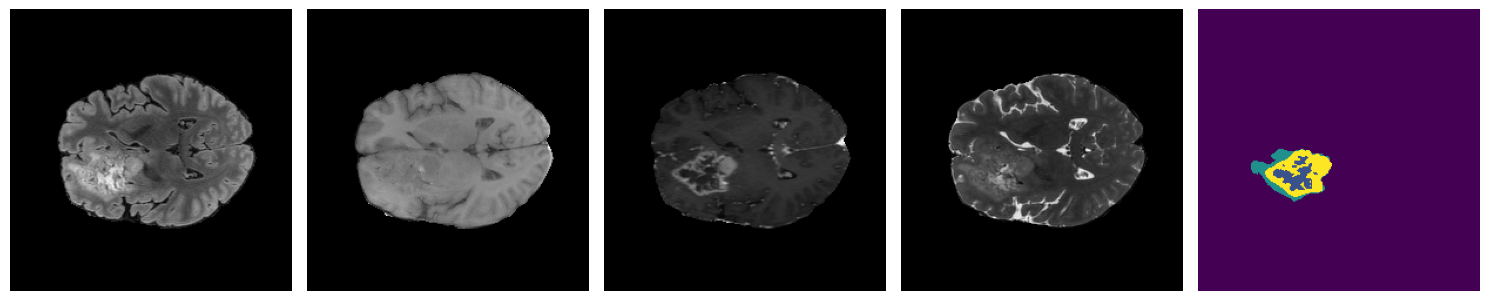

[0, 1, 2, 4]


In [8]:
imgs = [
    nib.load(f".raw/BraTS2021_Training_Data/BraTS2021_00000/BraTS2021_00000_{m}.nii.gz")
    .get_fdata()
    .astype(np.float32)[:, :, 75]
    for m in ["flair", "t1", "t1ce", "t2"]
]
lbl = (
    nib.load(".raw/BraTS2021_Training_Data/BraTS2021_00000/BraTS2021_00000_seg.nii.gz")
    .get_fdata()
    .astype(np.uint8)[:, :, 75]
)
fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(15, 15))
for i, img in enumerate(imgs):
    ax[i].imshow(img, cmap="gray")
    ax[i].axis("off")
ax[-1].imshow(lbl, vmin=0, vmax=4)
ax[-1].axis("off")
plt.tight_layout()
plt.show()
print(np.unique(lbl.flatten()).tolist())

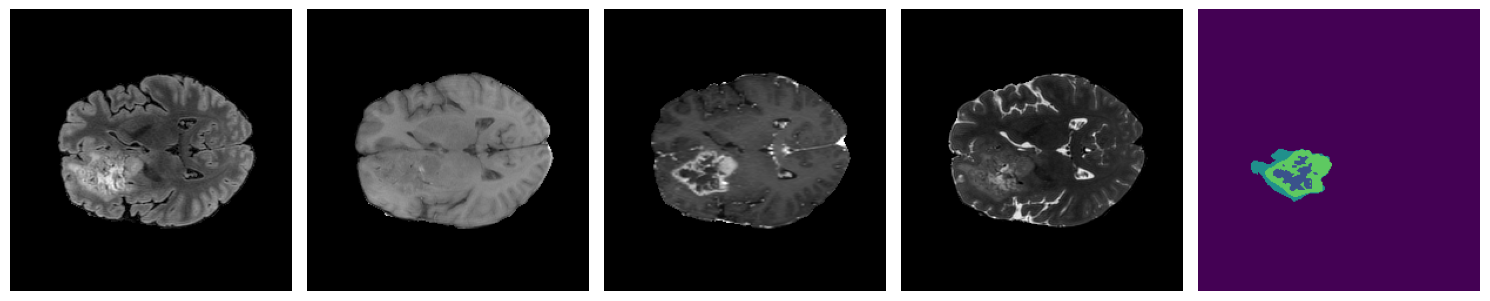

[0, 1, 2, 3]


In [25]:
imgs = [
    nib.load(f".processed/BraTS2021_00000/BraTS2021_00000_{m}.nii.gz")
    .get_fdata()
    .astype(np.float32)[:, :, 75]
    for m in ["flair", "t1", "t1ce", "t2"]
]
lbl = (
    nib.load(".processed/BraTS2021_00000/BraTS2021_00000_seg.nii.gz")
    .get_fdata()
    .astype(np.uint8)[:, :, 75]
)
fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(15, 15))
for i, img in enumerate(imgs):
    ax[i].imshow(img, cmap="gray")
    ax[i].axis("off")
ax[-1].imshow(lbl, vmin=0, vmax=4)
ax[-1].axis("off")
plt.tight_layout()
plt.show()
print(np.unique(lbl.flatten()).tolist())

In [24]:
imgs = [
    nib.load(f".raw/BraTS2021_Training_Data/BraTS2021_00000/BraTS2021_00000_{m}.nii.gz")
    # .get_fdata()
    # .astype(np.float32)
    for m in ["flair", "t1", "t1ce", "t2"]
]
imgs
t = np.stack(imgs, axis=-1)

print(imgs[0].header)

<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3 240 240 155   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [1. 1. 1. 1. 0. 0. 0. 0.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 2
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b''
aux_file        : b''
qform_code      : scanner
sform_code      : scanner
quatern_b       : 0.0
quatern_c       : 0.0
quatern_d       : 1.0
qoffset_x       : 0.0
qoffset_y       : 239.0
qoffset_z       : 0.0
srow_x          : [-1. -0. -0.  0.]
srow_y          : 

# Preprocessing


In [ ]:
def load_nifty(directory, example_id, suffix):
    return nib.load(os.path.join(directory, example_id + "_" + suffix + ".nii.gz"))


def load_channels(d, example_id):
    return [
        load_nifty(d, example_id, suffix) for suffix in ["flair", "t1", "t1ce", "t2"]
    ]


def get_data(nifty, dtype="int16"):
    if dtype == "int16":
        data = np.abs(nifty.get_fdata().astype(np.int16))
        data[data == -32768] = 0
        return data
    return nifty.get_fdata().astype(np.uint8)


def prepare_nifty(d):
    example_id = d.split("/")[-1]
    flair, t1, t1ce, t2 = load_channels(d, example_id)
    affine, header = flair.affine, flair.header
    vol = np.stack(
        [get_data(flair), get_data(t1), get_data(t1ce), get_data(t2)], axis=-1
    )
    vol = nib.nifti1.Nifti1Image(vol, affine, header=header)
    nib.save(vol, os.path.join(d, example_id + ".nii.gz"))

    if os.path.exists(os.path.join(d, example_id + "_seg.nii.gz")):
        seg = load_nifty(d, example_id, "seg")
        affine, header = seg.affine, seg.header
        vol = get_data(seg, "unit8")
        vol[vol == 4] = 3
        seg = nib.nifti1.Nifti1Image(vol, affine, header=header)
        nib.save(seg, os.path.join(d, example_id + "_seg.nii.gz"))


def prepare_dirs(data, train):
    img_path, lbl_path = os.path.join(data, "images"), os.path.join(data, "labels")
    call(f"mkdir {img_path}", shell=True)
    if train:
        call(f"mkdir {lbl_path}", shell=True)
    dirs = glob(os.path.join(data, "BraTS*"))
    for d in dirs:
        if "_" in d.split("/")[-1]:
            files = glob(os.path.join(d, "*.nii.gz"))
            for f in files:
                if "flair" in f or "t1" in f or "t1ce" in f or "t2" in f:
                    continue
                if "_seg" in f:
                    call(f"mv {f} {lbl_path}", shell=True)
                else:
                    call(f"mv {f} {img_path}", shell=True)
        call(f"rm -rf {d}", shell=True)


def prepare_dataset_json(data, train):
    images, labels = (
        glob(os.path.join(data, "images", "*")),
        glob(os.path.join(data, "labels", "*")),
    )
    images = sorted([img.replace(data + "/", "") for img in images])
    labels = sorted([lbl.replace(data + "/", "") for lbl in labels])

    modality = {"0": "FLAIR", "1": "T1", "2": "T1CE", "3": "T2"}
    labels_dict = {
        "0": "background",
        "1": "edema",
        "2": "non-enhancing tumor",
        "3": "enhancing tumour",
    }
    if train:
        key = "training"
        data_pairs = [
            {"image": img, "label": lbl} for (img, lbl) in zip(images, labels)
        ]
    else:
        key = "test"
        data_pairs = [{"image": img} for img in images]

    dataset = {
        "labels": labels_dict,
        "modality": modality,
        key: data_pairs,
    }

    with open(os.path.join(data, "dataset.json"), "w") as outfile:
        json.dump(dataset, outfile)


def run_parallel(func, args):
    return Parallel(n_jobs=os.cpu_count())(delayed(func)(arg) for arg in args)


def prepare_dataset(data, train):
    print(f"Preparing BraTS21 dataset from: {data}")
    start = time.time()
    run_parallel(prepare_nifty, sorted(glob(os.path.join(data, "BraTS*"))))
    prepare_dirs(data, train)
    prepare_dataset_json(data, train)
    end = time.time()
    print(f"Preparing time: {(end - start):.2f}")


prepare_dataset("/data/BraTS2021_train", True)
prepare_dataset("/data/BraTS2021_val", False)
print("Finished!")

# Data Augmentation


# Loss Function


In [ ]:
import torch.nn as nn
from monai.losses import DiceLoss


class Loss(nn.Module):
    def __init__(self):
        super(Loss, self).__init__()
        self.dice = DiceLoss(sigmoid=True, batch=True)
        self.ce = nn.BCEWithLogitsLoss()

    def _loss(self, p, y):
        return self.dice(p, y) + self.ce(p, y.float())

    def forward(self, p, y):
        y_wt, y_tc, y_et = y > 0, ((y == 1) + (y == 3)) > 0, y == 3
        p_wt, p_tc, p_et = (
            p[:, 0].unsqueeze(1),
            p[:, 1].unsqueeze(1),
            p[:, 2].unsqueeze(1),
        )
        l_wt, l_tc, l_et = (
            self._loss(p_wt, y_wt),
            self._loss(p_tc, y_tc),
            self._loss(p_et, y_et),
        )
        return l_wt + l_tc + l_et

# Model


In [ ]:
from IPython.display import Image

Image(filename="../images/unet-brats.jpg")

!python ../main.py --brats --deep_supervision --depth 6 --filters 64 96 128 192 256 384 512 --min_fmap 2 --scheduler --learning_rate 0.0003 --epochs 30 --fold 0 --amp --gpus 1 --task 11 --save_ckpt

!python ../main.py --gpus 1 --amp --save_preds --exec_mode predict --brats --data /data/12_3d/test --ckpt_path /results/checkpoints/epoch=29-dice_mean=89.69.ckpt --tta

FileNotFoundError: [Errno 2] No such file or directory: '../images/unet-brats.jpg'

# Post processing


In [ ]:
import os
from glob import glob
from subprocess import call

import nibabel as nib
import numpy as np
from scipy.ndimage.measurements import label


def to_lbl(pred):
    enh = pred[2]
    c1, c2, c3 = pred[0] > 0.5, pred[1] > 0.5, pred[2] > 0.5
    pred = (c1 > 0).astype(np.uint8)
    pred[(c2 == False) * (c1 == True)] = 2
    pred[(c3 == True) * (c1 == True)] = 4

    components, n = label(pred == 4)
    for et_idx in range(1, n + 1):
        _, counts = np.unique(pred[components == et_idx], return_counts=True)
        if 1 < counts[0] and counts[0] < 8 and np.mean(enh[components == et_idx]) < 0.9:
            pred[components == et_idx] = 1

    et = pred == 4
    if 0 < et.sum() and et.sum() < 73 and np.mean(enh[et]) < 0.9:
        pred[et] = 1

    pred = np.transpose(pred, (2, 1, 0)).astype(np.uint8)
    return pred


def prepare_preditions(e):
    fname = e[0].split("/")[-1].split(".")[0]
    preds = [np.load(f) for f in e]
    p = to_lbl(np.mean(preds, 0))

    img = nib.load(f"/data/BraTS2021_val/images/{fname}.nii.gz")
    nib.save(
        nib.Nifti1Image(p, img.affine, header=img.header),
        os.path.join("/results/final_preds", fname + ".nii.gz"),
    )


os.makedirs("/results/final_preds")
preds = sorted(glob(f"/results/predictions*"))
examples = list(zip(*[sorted(glob(f"{p}/*.npy")) for p in preds]))
print("Preparing final predictions")
for e in examples:
    prepare_preditions(e)
print("Finished!")

# Visualization


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from glob import glob

n, z = 5, 75
data = sorted(glob("/results/final_preds/*.nii.gz"))
for i in range(n):
    fname = data[i].split("/")[-1].split(".")[0]
    print(fname)
    img = (
        nib.load(f"/data/BraTS2021_val/images/{fname}.nii.gz")
        .get_fdata()
        .astype(np.float32)
    )
    pred = nib.load(data[i]).get_fdata().astype(np.uint8)[:, :, z]
    imgs = [img[:, :, z, i] for i in [0, 3]] + [pred]

    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12, 12))
    for i in range(3):
        if i < 2:
            ax[i].imshow(imgs[i], cmap="gray")
        else:
            ax[i].imshow(imgs[i])
        ax[i].axis("off")
    plt.tight_layout()
    plt.show()